# はじめに

このノートではProphetライブラリをPythonで利用する方法をまとめておく。内容としては、時系列データの理解、特徴量エンジニアリング、クロスバリデーション、パラメタチューニング、将来の予測までをまとめる。時系列分析に関する数理的な要素や分析の正当性については、ここでは扱わない。時系列分析で必要な観点において、一連で実行できるようにまとめる。

- [prophet](https://facebook.github.io/prophet/)

In [4]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from prophet import Prophet
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import jpholiday

# ----------------------------
# ログ設定
# ----------------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ----------------------------
# 1. データ読み込み・前処理
# ----------------------------
def load_data(filepath):
    logger.info("Loading data from %s", filepath)
    df = pd.read_csv(filepath)[['date', 'pageviews']].rename(columns={'date': 'ds', 'pageviews': 'y'})
    df['ds'] = pd.to_datetime(df['ds'])
    df = df[df['ds'] >= '2018-07-01']
    logger.info("Data loaded and filtered: %d rows", len(df))
    return df

# ----------------------------
# 2. 未来データ追加
# ----------------------------
def add_future_dates(df, periods=7):
    logger.info("Adding %d future dates", periods)
    future_dates = pd.date_range(df['ds'].max() + pd.Timedelta(days=1), periods=periods)
    return pd.DataFrame({'ds': future_dates, 'y': np.nan})

# ----------------------------
# 3. 特徴量作成
# ----------------------------
def create_features(df):
    logger.info("Creating features")
    lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
    wins = lags
    expans = lags

    for lag in lags:
        df[f'lag{lag}'] = df['y'].shift(lag)

    for w in wins:
        df[f'win{w}'] = df['y'].shift(1).rolling(window=w, min_periods=1).mean()

    for exp in expans:
        df[f'expan{exp}'] = df[f'lag{exp}'].expanding().mean()

    df['weekday'] = df['ds'].dt.weekday
    weekday_dummies = pd.get_dummies(df['weekday'], prefix='wd', drop_first=False)
    df = pd.concat([df, weekday_dummies], axis=1)

    df['is_tuesday'] = df['ds'].dt.weekday == 1
    df['is_jholiday'] = df['ds'].apply(lambda x: jpholiday.is_holiday(x))

    regressors = [
        *[f'lag{l}' for l in lags],
        *[f'win{w}' for w in wins],
        *[f'expan{e}' for e in expans],
        *[f'wd_{i}' for i in range(7)],
        'is_tuesday',
        'is_jholiday'
    ]
    logger.info("Feature creation complete")
    return df, regressors

# ----------------------------
# 4. Optuna用Objective関数
# ----------------------------
def objective(trial, df, regressors):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10),
        'weekly_fourier': trial.suggest_int('weekly_fourier', 3, 7),
        'weekly_prior': trial.suggest_float('weekly_prior', 1, 12)
    }

    cv_mae = []
    tss = TimeSeriesSplit(n_splits=5)

    for train_idx, valid_idx in tss.split(df):
        train_data, valid_data = df.iloc[train_idx].copy(), df.iloc[valid_idx].copy()

        m = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='additive'
        )

        for reg in regressors:
            m.add_regressor(reg)

        m.add_seasonality('weekly', period=7, fourier_order=params['weekly_fourier'], prior_scale=params['weekly_prior'])
        m.fit(train_data)
        preds = m.predict(valid_data)
        mae = mean_absolute_error(valid_data['y'], preds['yhat'])
        cv_mae.append(mae)

    avg_mae = np.mean(cv_mae)
    logger.debug("Trial complete - MAE: %.4f", avg_mae)
    return avg_mae

# ----------------------------
# 5. Prophet モデル作成
# ----------------------------
def build_prophet_model(params, regressors):
    logger.info("Building Prophet model with best parameters")
    model = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive'
    )
    for reg in regressors:
        model.add_regressor(reg)
    model.add_seasonality('weekly', period=7, fourier_order=params['weekly_fourier'], prior_scale=params['weekly_prior'])
    return model

# ----------------------------
# 6. 再帰的予測
# ----------------------------
def recursive_forecast(df, model, feature_cols, future_index, lags, wins, expans):
    logger.info("Starting recursive forecast")
    for idx in future_index:
        for lag in lags:
            full_idx = idx - lag
            if full_idx in df.index:
                df.at[idx, f'lag{lag}'] = df.at[full_idx, 'yhat'] if pd.isna(df.at[full_idx, 'y']) else df.at[full_idx, 'y']

        for win in wins:
            lag_vals = [df.at[i, f'lag{win}'] for i in range(idx - win + 1, idx + 1) if i in df.index and not pd.isna(df.at[i, f'lag{win}'])]
            df.at[idx, f'win{win}'] = np.mean(lag_vals) if lag_vals else np.nan

        for expan in expans:
            exp_vals = [df.at[i, f'lag{expan}'] for i in range(0, idx) if not pd.isna(df.at[i, f'lag{expan}'])]
            df.at[idx, f'expan{expan}'] = np.mean(exp_vals) if exp_vals else np.nan

        input_row = df.loc[[idx], ['ds'] + feature_cols]
        forecast = model.predict(input_row)
        df.at[idx, 'yhat'] = forecast.at[0, 'yhat']
        df.at[idx, 'yhat_lower'] = forecast.at[0, 'yhat_lower']
        df.at[idx, 'yhat_upper'] = forecast.at[0, 'yhat_upper']
    logger.info("Recursive forecast complete")
    return df

# ----------------------------
# 7. 予測プロット関数
# ----------------------------
def plot_forecast(df):
    logger.info("Plotting forecast")
    plt.figure(figsize=(14, 6))
    plt.plot(df['ds'], df['y'], label='Actual (y)', color='gray', alpha=0.7)
    plt.plot(df['ds'], df['yhat'], label='Forecast (yhat)', color='#006E4F')
    plt.fill_between(df['ds'], df['yhat_lower'], df['yhat_upper'], color='#006E4F', alpha=0.1, label='Confidence Interval')
    plt.axvline(pd.to_datetime('2019-09-01'), color='gray', linestyle='--', alpha=0.7, label='Forecast Start')
    plt.title('Forecast plot')
    plt.xlabel('Date')
    plt.ylabel('y')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    plt.show()


2025-08-10 15:27:25,167 - INFO - Pipeline started
2025-08-10 15:27:25,168 - INFO - Loading data from ./data/GoogleAnalytics_TimeSeriesData.csv
2025-08-10 15:27:25,178 - INFO - Data loaded and filtered: 427 rows
2025-08-10 15:27:25,179 - INFO - Adding 7 future dates
2025-08-10 15:27:25,182 - INFO - Creating features
2025-08-10 15:27:25,195 - INFO - Feature creation complete
2025-08-10 15:27:25,198 - INFO - Starting hyperparameter tuning
2025-08-10 15:27:25,299 - DEBUG - input tempfile: /var/folders/s7/r__8fgpd56l0s3kgg97276280000gn/T/tmpe0t_iqki/os6www5u.json
2025-08-10 15:27:25,300 - DEBUG - input tempfile: /var/folders/s7/r__8fgpd56l0s3kgg97276280000gn/T/tmpe0t_iqki/vh4li34h.json
2025-08-10 15:27:25,300 - DEBUG - input tempfile: /var/folders/s7/r__8fgpd56l0s3kgg97276280000gn/T/tmpe0t_iqki/1h5dr5p0.json
2025-08-10 15:27:25,315 - DEBUG - input tempfile: /var/folders/s7/r__8fgpd56l0s3kgg97276280000gn/T/tmpe0t_iqki/d3k_49i_.json
2025-08-10 15:27:25,318 - DEBUG - input tempfile: /var/folde

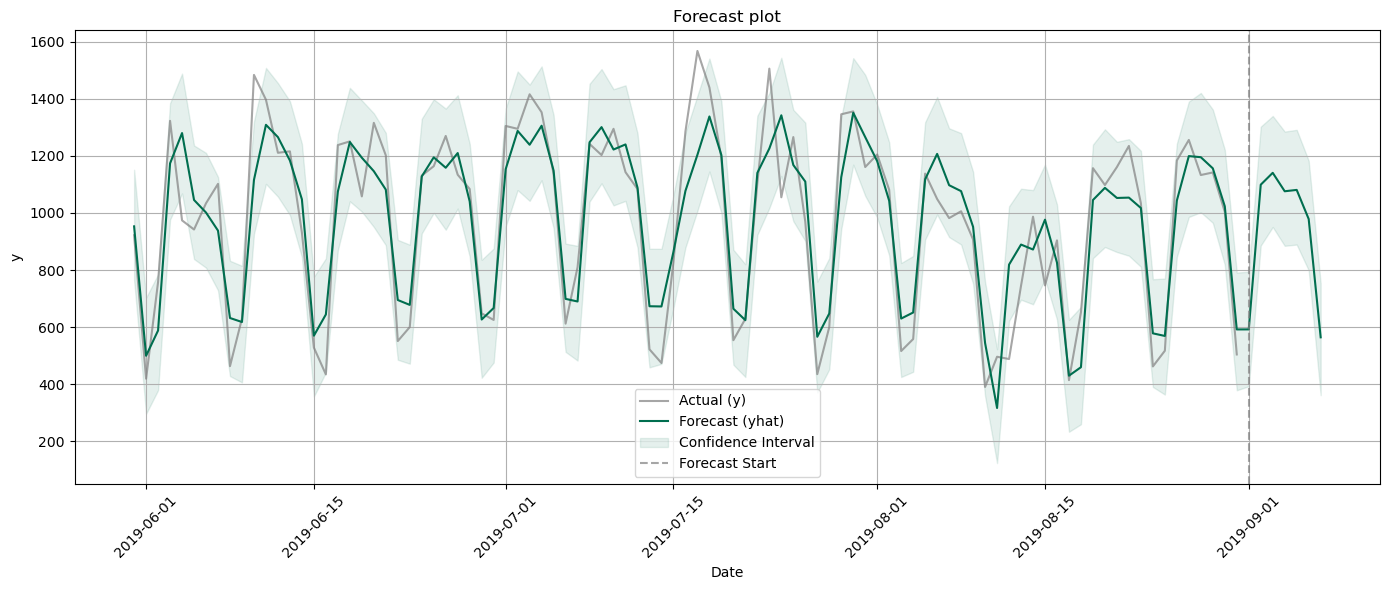

2025-08-10 15:28:20,629 - INFO - Pipeline completed


In [ ]:
# ----------------------------
# メイン処理
# ----------------------------
if __name__ == '__main__':
    # パイプライン開始ログ
    logger.info("Pipeline started")
    # データ読み込み
    df = load_data('./data/GoogleAnalytics_TimeSeriesData.csv')
    # 未来の空データ追加
    forecast_df = add_future_dates(df)
    # 過去＋未来データを統合
    full_df = pd.concat([df, forecast_df], ignore_index=True)

    # 特徴量作成
    full_df, regressors = create_features(full_df)
    # 特徴量列のリスト作成
    feature_cols = full_df.columns.difference(['ds', 'y']).tolist()

    # 学習/評価用データ抽出（欠損除外）
    train_test_df = full_df[full_df[feature_cols].notna().all(axis=1) & full_df['y'].notna()].copy()
    # 学習・テストに分割
    train_df, test_df = train_test_split(train_test_df, test_size=62)

    # Optuna によるハイパーパラメータチューニング開始
    logger.info("Starting hyperparameter tuning")
    # Optuna サイレント設定 + study作成
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    # 最適化実行
    study.optimize(lambda trial: objective(trial, train_df, regressors), n_trials=100, n_jobs=4)

    # 最良パラメータ取得
    best_params = study.best_params
    logger.info("Best params found: %s", best_params)

    # モデル構築（テスト用）
    model = build_prophet_model(best_params, regressors)
    # テスト用モデル学習
    model.fit(train_df)
    
    # テストデータ予測
    pred = model.predict(test_df)
    mae = mean_absolute_error(test_df['y'], pred['yhat'])
    logger.info("Test MAE: %.4f", mae)

    # フルモデル構築＆学習（テスト＋学習データ）
    full_model = build_prophet_model(best_params, regressors)
    full_model.fit(train_test_df)

    # 再帰予測のための未来インデックス取得
    future_index = full_df[full_df['y'].isna()].index
    lags = [1,2,3,4,5,6,7,14,21,28]
    wins = lags
    expans = lags
    # 再帰的に未来を予測
    full_df = recursive_forecast(full_df, full_model, feature_cols, future_index, lags, wins, expans)

    # 予測結果のデータフレーム作成
    logger.info("Generating result DataFrame")
    pred_train = train_df.merge(full_model.predict(train_df), on='ds', how='left')
    pred_test = test_df.merge(full_model.predict(test_df), on='ds', how='left')
    pred_forecast = full_df.loc[future_index, ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]

    # 予測・実測の結合（直近100件）
    result_df = pd.concat([
        pred_train[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
        pred_test[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
        pred_forecast
    ]).sort_values('ds').tail(100)

    # プロット表示
    plot_forecast(result_df)
    # パイプライン完了ログ
    logger.info("Pipeline completed")

In [30]:
train_df

,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,weekday,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday
28,2018-07-29,279.0,316.0,599.0,568.0,665.0,762.0,562.0,220.0,324.0,...,6,False,False,False,False,False,False,True,False,False
29,2018-07-30,677.0,279.0,316.0,599.0,568.0,665.0,762.0,562.0,418.0,...,0,True,False,False,False,False,False,False,False,False
30,2018-07-31,620.0,677.0,279.0,316.0,599.0,568.0,665.0,762.0,742.0,...,1,False,True,False,False,False,False,False,True,False
31,2018-08-01,697.0,620.0,677.0,279.0,316.0,599.0,568.0,665.0,653.0,...,2,False,False,True,False,False,False,False,False,False
32,2018-08-02,679.0,697.0,620.0,677.0,279.0,316.0,599.0,568.0,608.0,...,3,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2019-06-26,1270.0,1164.0,1131.0,600.0,551.0,1202.0,1316.0,1058.0,1211.0,...,2,False,False,True,False,False,False,False,False,False
361,2019-06-27,1134.0,1270.0,1164.0,1131.0,600.0,551.0,1202.0,1316.0,1216.0,...,3,False,False,False,True,False,False,False,False,False
362,2019-06-28,1084.0,1134.0,1270.0,1164.0,1131.0,600.0,551.0,1202.0,931.0,...,4,False,False,False,False,True,False,False,False,False
363,2019-06-29,648.0,1084.0,1134.0,1270.0,1164.0,1131.0,600.0,551.0,528.0,...,5,False,False,False,False,False,True,False,False,False


In [31]:
test_df

,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,weekday,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday
365,2019-07-01,1305.0,625.0,648.0,1084.0,1134.0,1270.0,1164.0,1131.0,1238.0,...,0,True,False,False,False,False,False,False,False,False
366,2019-07-02,1295.0,1305.0,625.0,648.0,1084.0,1134.0,1270.0,1164.0,1251.0,...,1,False,True,False,False,False,False,False,True,False
367,2019-07-03,1416.0,1295.0,1305.0,625.0,648.0,1084.0,1134.0,1270.0,1058.0,...,2,False,False,True,False,False,False,False,False,False
368,2019-07-04,1353.0,1416.0,1295.0,1305.0,625.0,648.0,1084.0,1134.0,1316.0,...,3,False,False,False,True,False,False,False,False,False
369,2019-07-05,1137.0,1353.0,1416.0,1295.0,1305.0,625.0,648.0,1084.0,1202.0,...,4,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,2019-08-27,1256.0,1184.0,517.0,462.0,1034.0,1235.0,1161.0,1098.0,745.0,...,1,False,True,False,False,False,False,False,True,False
423,2019-08-28,1133.0,1256.0,1184.0,517.0,462.0,1034.0,1235.0,1161.0,987.0,...,2,False,False,True,False,False,False,False,False,False
424,2019-08-29,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,1235.0,746.0,...,3,False,False,False,True,False,False,False,False,False
425,2019-08-30,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,904.0,...,4,False,False,False,False,True,False,False,False,False


In [32]:
forecast_df

,ds,y
0,2019-09-01,NaN
1,2019-09-02,NaN
2,2019-09-03,NaN
3,2019-09-04,NaN
4,2019-09-05,NaN
5,2019-09-06,NaN
6,2019-09-07,NaN
